# Trackmania Monte Carlo Simulator — Exploration


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from tmonacodel import TournamentConfig, run_monte_carlo, REAL_PLAYERS
from tmonacodel.racer import make_racer_pool

sns.set_theme(style='whitegrid')

## Run simulation


In [2]:
config = TournamentConfig(n_simulations=10_000, random_seed=None)
results = run_monte_carlo(config, player_data=REAL_PLAYERS)
print(f'Simulated {config.n_simulations} seasons with {config.n_players} players')
print(f'Real players: {len(REAL_PLAYERS)}, Generic fill: {config.n_players - len(REAL_PLAYERS)}')

Simulated 10000 seasons with 120 players
Real players: 98, Generic fill: 22


## Summary table


In [3]:
df = results.summary_dataframe()
df[['name', 'country', 'mean_rank', 'median_rank', 'prob_top_N']].head(20)

,name,country,mean_rank,median_rank,prob_top_N
0,eLconn21,Czechia,59.6874,60.0,0.1418
1,Snow,France,59.7303,59.0,0.1342
2,Jan123405,Slovenia,59.7470,59.0,0.1391
3,Eria,Belgium,59.7982,59.0,0.1366
4,Carl Jr.,Canada,59.8112,60.0,0.1346
5,Nayko,France,59.8116,59.0,0.1313
6,Kurisu-tina,Italy,59.8649,60.0,0.1376
7,Flimsy,United States,59.8706,60.0,0.1334
8,Pika,Portugal,59.8766,59.0,0.1362
9,Whizzy,United Kingdom,59.8964,60.0,0.1364


## EWC Qualifying Score (PQ)

In [4]:
pq = results.ewc_qualifying_score(top_n=8)
print(f"PQ (guaranteed top-8 qualifying score): {pq} points")

PQ (guaranteed top-8 qualifying score): 1680 points


## Qualification likelihood by score

In [5]:
curve = results.ewc_qualification_curve(top_n=8, step=50)
print(curve.to_string(index=False))

 score  pq_offset  prob_qualify
  1680          0        1.0000
  1630         50        0.9997
  1580        100        0.9992
  1530        150        0.9966
  1480        200        0.9904
  1430        250        0.9739
  1380        300        0.9387
  1330        350        0.8737
  1280        400        0.7540
  1230        450        0.5042
  1180        500        0.1820
  1130        550        0.0203
  1080        600        0.0007
  1030        650        0.0000


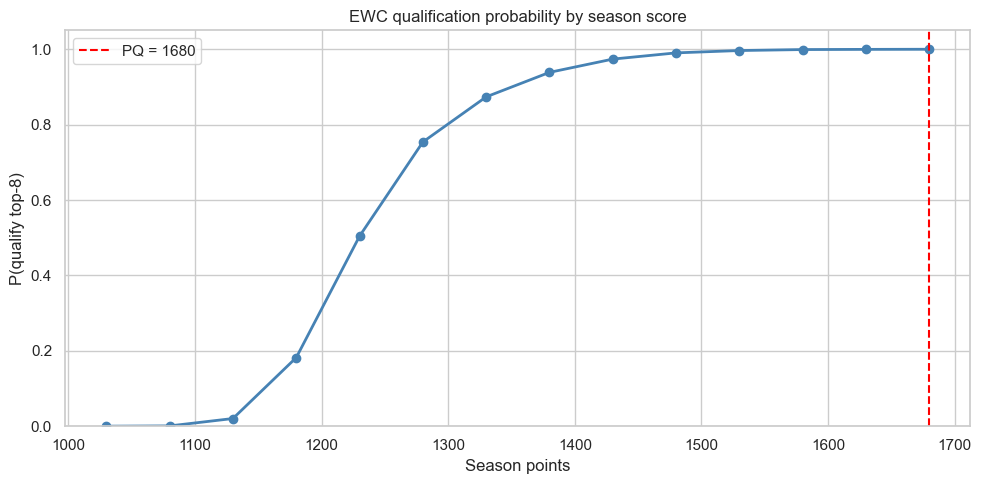

In [6]:
curve_plot = curve.sort_values("score")
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(curve_plot["score"], curve_plot["prob_qualify"], marker="o", linewidth=2, color="steelblue")
ax.axvline(pq, color="red", linestyle="--", label=f"PQ = {pq}")
ax.set_xlabel("Season points")
ax.set_ylabel("P(qualify top-8)")
ax.set_title("EWC qualification probability by season score")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Minimum score to top national table

In [9]:
nation_tops = results.nation_topping_scores()
nation_tops

,country,player_count,min_score_to_top_nation
0,Germany,14,4060
1,Norway,2,3784
2,Netherlands,3,3700
3,France,32,3700
4,Slovenia,2,3676
5,Slovakia,4,3660
6,Poland,12,3600
7,Turkey,4,3588
8,United States,7,3468
9,United Kingdom,8,3400


## Average points by finishing rank

In [7]:
rank_df = results.rank_points_profile()
print(rank_df.to_string(index=False))

 rank  mean_points  p10_points  p90_points
    1       2107.7        1730        2574
    2       1802.4        1536        2108
    3       1636.9        1414        1856
    4       1519.2        1320        1732
    5       1424.6        1256        1608
    6       1349.1        1218        1508
    7       1289.8        1188        1420
    8       1244.6        1164        1348
    9       1209.8        1142        1288
   10       1181.0        1120        1248
   11       1155.1        1096        1216
   12       1129.8        1070        1190
   13       1102.7        1034        1166
   14       1071.1         976        1144
   15       1035.3         932        1120
   16        997.5         900        1092
   17        961.4         876        1060
   18        928.8         856        1022
   19        900.8         838         976
   20        877.3         820         940
   21        856.6         806         912
   22        838.2         790         890
   23      

## Plot: Qualification probability distribution


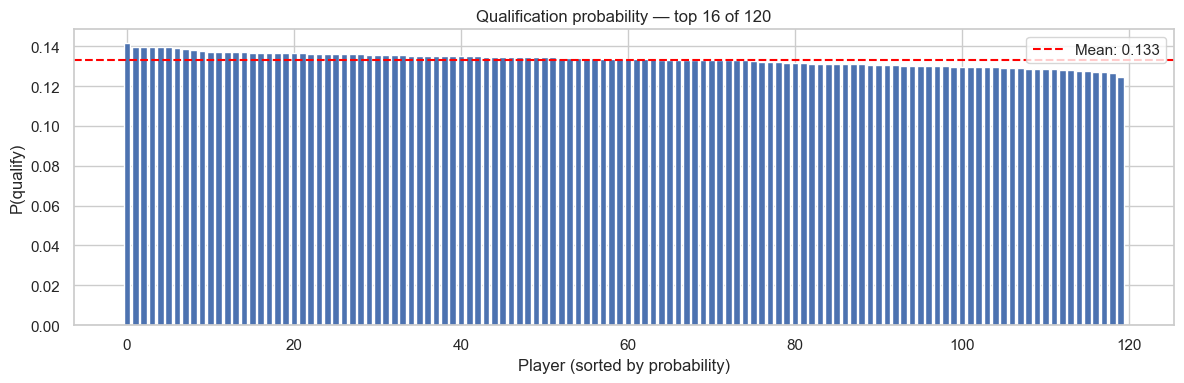

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(probs)), probs.values)
ax.axhline(probs.mean(), color='red', linestyle='--', label=f'Mean: {probs.mean():.3f}')
ax.set_xlabel('Player (sorted by probability)')
ax.set_ylabel('P(qualify)')
ax.set_title(f'Qualification probability — top {config.top_n_cutoff} of {config.n_players}')
ax.legend()
plt.tight_layout()
plt.show()

## Plot: Points distribution for one player


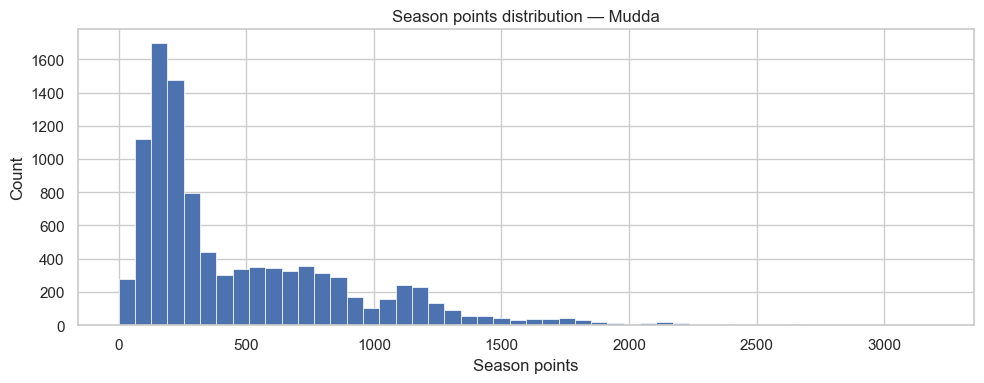

In [11]:
racer_id = 0
dist = results.points_distribution(racer_id)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist, bins=50, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Season points')
ax.set_ylabel('Count')
ax.set_title(f'Season points distribution — {results.racers[racer_id].name}')
plt.tight_layout()
plt.show()